# nb06 -- Confound-corrected sparse MLP: RNA -> protein
Extends nb05 with two corrections:

1. **Library-size regression** -- removes the "everything scales together" artifact (ACTB/EEF1A1/HBB dominating as top predictors in nb05) by regressing out per-cell RNA and ADT library size before training. This is a technical confound, not biology, so it's removed.
2. **Cell-type-stratified training** -- trains a separate model per cell type on the corrected residuals, so genuine cell-type-specific coupling (the real effector/naive-style gradient from nb02) is preserved rather than averaged away.

Training runs on GPU; validation during training and all post-training evaluation run on CPU.

## Environment setup

In [1]:
from pathlib import Path

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !pip install -q scanpy anndata scikit-misc
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = Path('/content/drive/MyDrive/covid_citeseq_project')
else:
    BASE_PATH = Path('..')

print(f"Running on {'Colab' if IN_COLAB else 'local'} | BASE_PATH = {BASE_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Running on Colab | BASE_PATH = /content/drive/MyDrive/covid_citeseq_project


In [2]:
!pip install -q -U "typing_extensions>=4.13"


## GPU check

In [3]:
import torch

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device (training only):', DEVICE)

Device (training only): cuda


## Imports and config

In [4]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import scanpy as sc
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

CHECKPOINT_PATH    = BASE_PATH / 'data' / 'processed' / 'covid_subsampled.h5ad'
GENE_MAPPING_PATH  = BASE_PATH / 'results' / 'tables' / 'nb02_covid_adt_gene_mapping.csv'
RESULTS_DIR        = BASE_PATH / 'results' / 'sparse_mlp_corrected'
MODELS_DIR         = RESULTS_DIR / 'checkpoints'
FIGURES_DIR        = RESULTS_DIR / 'figures'
for d in (MODELS_DIR, FIGURES_DIR):
    d.mkdir(parents=True, exist_ok=True)

N_HVGS       = 2000
DROP_GENES   = ['PDPN', 'KDR']  # zero-variance in GEX (see nb02 Step 3b)

HIDDEN_DIM   = 64
L1_LAMBDA    = 1e-4
BATCH_SIZE   = 256
NUM_EPOCHS   = 100
PATIENCE     = 15

TEST_SIZE     = 0.15
VAL_SIZE      = 0.15
RANDOM_STATE  = 42

MIN_CELLS_PER_TYPE = 500   # skip cell types too small to fit reliably
N_PLOT_PAIRS        = 12   # how many pairs to show inline (full set always saved to PDF)

## Load checkpoint and gene mapping
Same as nb03/nb05.

In [5]:
covid = sc.read_h5ad(CHECKPOINT_PATH)

gex_mask = covid.var['feature_types'] == 'Gene Expression'
adt_mask = covid.var['feature_types'] == 'Antibody Capture'
covid_gex = covid[:, gex_mask].copy()
covid_adt = covid[:, adt_mask].copy()

gene_map = pd.read_csv(GENE_MAPPING_PATH)
gene_map = gene_map[~gene_map['gene'].isin(DROP_GENES)]
matched_genes     = gene_map['gene'].tolist()
matched_adt_names = gene_map['adt_name'].tolist()

print(f'GEX: {covid_gex.shape}, ADT: {covid_adt.shape}')
print(f'Matched genes/proteins: {len(matched_genes)}')

GEX: (69090, 24737), ADT: (69090, 192)
Matched genes/proteins: 163


## Identify the cell-type column
nb03 never used cell type, so the exact `obs` column name isn't established yet -- print all columns and auto-detect likely candidates. **Check the printed list and set `CELL_TYPE_COL` manually below if the guess is wrong** before running the rest of the notebook.

In [6]:
print('All obs columns:')
print(covid.obs.columns.tolist())

candidates = [c for c in covid.obs.columns if any(
    kw in c.lower() for kw in ['cell_type', 'celltype', 'cluster', 'annotation', 'subset', 'lineage']
)]
print('\nLikely cell-type columns:', candidates)

All obs columns:
['sample_id', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'full_clustering', 'initial_clustering', 'Resample', 'Collection_Day', 'Sex', 'Age_interval', 'Swab_result', 'Status', 'Smoker', 'Status_on_day_collection', 'Status_on_day_collection_summary', 'Days_from_onset', 'Site', 'time_after_LPS', 'Worst_Clinical_Status', 'Outcome', 'patient_id']

Likely cell-type columns: ['full_clustering', 'initial_clustering']


In [7]:
# CONFIRM/OVERRIDE this before proceeding -- pick the column that holds cell-type labels.
CELL_TYPE_COL = candidates[0] if candidates else 'full_clustering'

print(f'Using CELL_TYPE_COL = "{CELL_TYPE_COL}"')
print(covid.obs[CELL_TYPE_COL].value_counts())

Using CELL_TYPE_COL = "full_clustering"
full_clustering
CD4.CM                   12501
NK_16hi                   8646
CD4.Naive                 6759
B_naive                   5922
CD8.Naive                 5587
CD4.IL22                  5488
CD8.TE                    2857
CD83_CD14_mono            2505
CD8.EM                    2431
CD4.Tfh                   2419
Platelets                 2245
gdT                       1897
MAIT                      1763
NK_56hi                   1182
RBC                       1079
B_switched_memory         1062
B_immature                 724
B_non-switched_memory      422
DC3                        393
NKT                        366
B_exhausted                268
Plasma_cell_IgG            247
CD4.EM                     246
Plasma_cell_IgA            238
CD4.Th1                    193
NK_prolif                  193
CD16_mono                  184
pDC                        171
ILC1_3                     156
Treg                       151
Plasmablast   

## Gene union (matched + HVG)
Same construction as nb03/nb05.

In [8]:
covid_gex.layers['counts'] = covid_gex.layers['raw'].copy()

sc.pp.highly_variable_genes(
    covid_gex, n_top_genes=N_HVGS, flavor='seurat_v3', layer='counts',
)
hvg_genes = covid_gex.var_names[covid_gex.var['highly_variable']].tolist()


def build_gene_union(matched_genes: list[str], hvg_genes: list[str]) -> list[str]:
    """Union of matched coupling genes and top HVGs, matched genes always included."""
    return sorted(set(matched_genes) | set(hvg_genes))


gene_union = build_gene_union(matched_genes, hvg_genes)
print(f'Gene union: {len(gene_union)}')

Gene union: 2092


## Normalize RNA and protein (pre-totalVI), same as nb05
RNA: log1p(CP10k). Protein: CLR. Both independent of totalVI's batch-corrected output.

In [9]:
def normalize_rna(adata_gex: sc.AnnData, gene_union: list[str]) -> sc.AnnData:
    """Log1p(CP10k) normalization on raw counts, restricted to gene_union."""
    adata = adata_gex[:, gene_union].copy()
    adata.X = adata.layers['raw'].copy()
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    return adata


def clr_normalize(counts: np.ndarray) -> np.ndarray:
    """Centered log-ratio normalization per cell -- standard for CITE-seq ADT counts."""
    log_counts = np.log1p(counts)
    geometric_mean = log_counts.mean(axis=1, keepdims=True)
    return log_counts - geometric_mean


rna_adata = normalize_rna(covid_gex, gene_union)
X_rna = np.asarray(rna_adata.X.todense()) if hasattr(rna_adata.X, 'todense') else np.asarray(rna_adata.X)
X_rna = X_rna.astype(np.float32)

adt_counts = covid_adt[:, matched_adt_names].layers['raw']
adt_counts = np.asarray(adt_counts.todense()) if hasattr(adt_counts, 'todense') else np.asarray(adt_counts)
Y_protein = clr_normalize(adt_counts).astype(np.float32)

cell_types = covid.obs[CELL_TYPE_COL].values

print(f'X_rna: {X_rna.shape} | Y_protein: {Y_protein.shape}')

X_rna: (69090, 2092) | Y_protein: (69090, 163)


## Library-size correction (option a)
Regress each gene/protein on its modality's per-cell log library size and keep the residual. This removes the technical "cells with more total RNA/protein have higher everything" effect -- the likely source of ACTB/EEF1A1/HBB dominating nb05's importance rankings -- without touching cell-type identity itself. Vectorized closed-form OLS: same covariate for every column, solved once via `lstsq`.

In [10]:
def regress_out_library_size(X: np.ndarray, raw_counts_layer: np.ndarray) -> np.ndarray:
    """Residualize each column of X against log1p(per-cell total raw counts).

    X                : (n_cells, n_features) normalized values to correct.
    raw_counts_layer : (n_cells, n_features_raw) raw counts used only to compute library size.
    """
    lib_size = np.log1p(np.asarray(raw_counts_layer).sum(axis=1)).reshape(-1, 1)
    design = np.column_stack([np.ones(X.shape[0]), lib_size])
    beta, _, _, _ = np.linalg.lstsq(design, X, rcond=None)  # (2, n_features)
    return (X - design @ beta).astype(np.float32)


rna_raw_for_size = rna_adata.layers['raw'] if hasattr(rna_adata.layers['raw'], 'sum') else rna_adata.layers['raw']
rna_raw_for_size = np.asarray(rna_raw_for_size.todense()) if hasattr(rna_raw_for_size, 'todense') else np.asarray(rna_raw_for_size)

X_rna_corr     = regress_out_library_size(X_rna, rna_raw_for_size)
Y_protein_corr = regress_out_library_size(Y_protein, adt_counts)

print('Corrected X_rna and Y_protein via library-size regression.')

Corrected X_rna and Y_protein via library-size regression.


## Train / val / test split
Same simple random 70/15/15 split as nb05.

In [11]:
n_cells = X_rna_corr.shape[0]
all_idx = np.arange(n_cells)

train_idx, test_idx = train_test_split(all_idx, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_idx, val_idx  = train_test_split(train_idx, test_size=VAL_SIZE / (1 - TEST_SIZE), random_state=RANDOM_STATE)

print(f'Train: {len(train_idx):,} | Val: {len(val_idx):,} | Test: {len(test_idx):,}')

Train: 48,362 | Val: 10,364 | Test: 10,364


## DataLoaders (global model)

In [12]:
def make_loader(X: np.ndarray, Y: np.ndarray, idx: np.ndarray, batch_size: int, shuffle: bool) -> DataLoader:
    ds = TensorDataset(torch.from_numpy(X[idx]), torch.from_numpy(Y[idx]))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=shuffle)


train_loader = make_loader(X_rna_corr, Y_protein_corr, train_idx, BATCH_SIZE, shuffle=True)
val_loader   = make_loader(X_rna_corr, Y_protein_corr, val_idx,   BATCH_SIZE, shuffle=False)

## `SparseGeneToProteinMLP` architecture
Unchanged from nb05.

In [13]:
class SparseGeneToProteinMLP(nn.Module):
    """RNA -> hidden -> protein, multi-output regression.

    rna_dim     : number of input genes.
    hidden_dim  : hidden layer width.
    protein_dim : number of output proteins, predicted jointly.
    """

    def __init__(self, rna_dim: int, hidden_dim: int, protein_dim: int):
        super().__init__()
        self.fc1 = nn.Linear(rna_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, protein_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.fc2(self.relu(self.fc1(x)))

## Training loop -- GPU for training, CPU for validation
Model moves to GPU only for the training pass each epoch; validation runs with the model on CPU. Final returned model is left on CPU, matching the CPU-only evaluation that follows.

In [14]:
def fit_sparse_mlp(model: nn.Module,
                    train_loader: DataLoader,
                    val_loader: DataLoader,
                    l1_lambda: float,
                    num_epochs: int,
                    patience: int,
                    checkpoint_path: Path,
                    train_device: torch.device):
    """Train with MSE + L1(fc1.weight) on train_device; validate on CPU each epoch."""
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    history = {'train_loss': [], 'val_loss': []}
    best_val_loss = float('inf')
    best_state = None
    epochs_no_improve = 0

    for epoch in range(num_epochs):
        model.to(train_device)
        model.train()
        total_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(train_device), yb.to(train_device)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb) + l1_lambda * model.fc1.weight.abs().sum()
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * xb.size(0)
        train_loss = total_loss / len(train_loader.dataset)

        model.to('cpu')
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                val_loss += criterion(model(xb), yb).item() * xb.size(0)
        val_loss /= len(val_loader.dataset)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f'  Early stopping at epoch {epoch}')
                break

        if epoch % 10 == 0:
            print(f'  Epoch {epoch}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}')

    model.load_state_dict(best_state)
    model.to('cpu')
    torch.save(model.state_dict(), checkpoint_path)
    return model, history

## Train the global model (all cells, corrected residuals)

In [15]:
print('Training global model...')
global_model = SparseGeneToProteinMLP(
    rna_dim=X_rna_corr.shape[1], hidden_dim=HIDDEN_DIM, protein_dim=Y_protein_corr.shape[1],
)
global_model, global_history = fit_sparse_mlp(
    model=global_model,
    train_loader=train_loader,
    val_loader=val_loader,
    l1_lambda=L1_LAMBDA,
    num_epochs=NUM_EPOCHS,
    patience=PATIENCE,
    checkpoint_path=MODELS_DIR / 'global_model.pt',
    train_device=DEVICE,
)

Training global model...
  Epoch 0: train_loss=0.3288, val_loss=0.2774
  Epoch 10: train_loss=0.2787, val_loss=0.2608
  Epoch 20: train_loss=0.2756, val_loss=0.2578
  Epoch 30: train_loss=0.2743, val_loss=0.2576
  Epoch 40: train_loss=0.2736, val_loss=0.2560
  Epoch 50: train_loss=0.2732, val_loss=0.2556
  Epoch 60: train_loss=0.2727, val_loss=0.2557
  Epoch 70: train_loss=0.2728, val_loss=0.2556
  Epoch 80: train_loss=0.2724, val_loss=0.2557
  Epoch 90: train_loss=0.2724, val_loss=0.2552
  Early stopping at epoch 97


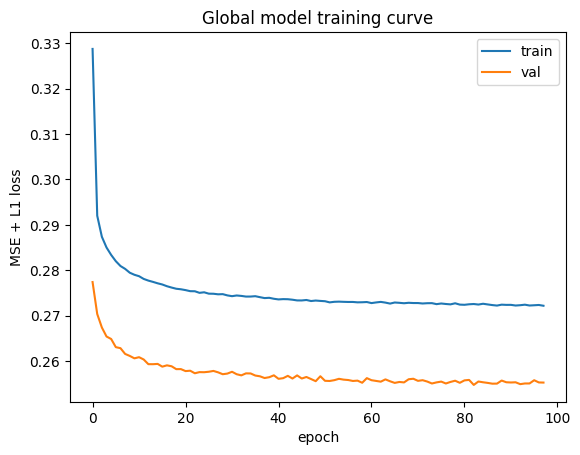

In [16]:
plt.plot(global_history['train_loss'], label='train')
plt.plot(global_history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('MSE + L1 loss')
plt.legend()
plt.title('Global model training curve')
plt.show()

## Train cell-type-stratified models (option c)
One model per cell type with enough cells, trained on the same corrected residuals but restricted to that cell type. Real cell-type-specific coupling is allowed to differ; nothing is forced equal across cell types.

In [17]:
type_counts = pd.Series(cell_types).value_counts()
fit_types = type_counts[type_counts >= MIN_CELLS_PER_TYPE].index.tolist()
print(f'Fitting {len(fit_types)} cell types (>= {MIN_CELLS_PER_TYPE} cells): {fit_types}')

celltype_models = {}
celltype_histories = {}
celltype_splits = {}

for ct in fit_types:
    print(f'\n--- {ct} ---')
    ct_idx = np.where(cell_types == ct)[0]

    ct_train, ct_test = train_test_split(ct_idx, test_size=TEST_SIZE, random_state=RANDOM_STATE)
    ct_train, ct_val  = train_test_split(ct_train, test_size=VAL_SIZE / (1 - TEST_SIZE), random_state=RANDOM_STATE)
    celltype_splits[ct] = {'train': ct_train, 'val': ct_val, 'test': ct_test}

    ct_train_loader = make_loader(X_rna_corr, Y_protein_corr, ct_train, BATCH_SIZE, shuffle=True)
    ct_val_loader   = make_loader(X_rna_corr, Y_protein_corr, ct_val,   BATCH_SIZE, shuffle=False)

    ct_model = SparseGeneToProteinMLP(
        rna_dim=X_rna_corr.shape[1], hidden_dim=HIDDEN_DIM, protein_dim=Y_protein_corr.shape[1],
    )
    safe_name = ct.replace(' ', '_').replace('/', '_')
    ct_model, ct_history = fit_sparse_mlp(
        model=ct_model,
        train_loader=ct_train_loader,
        val_loader=ct_val_loader,
        l1_lambda=L1_LAMBDA,
        num_epochs=NUM_EPOCHS,
        patience=PATIENCE,
        checkpoint_path=MODELS_DIR / f'celltype_{safe_name}.pt',
        train_device=DEVICE,
    )
    celltype_models[ct] = ct_model
    celltype_histories[ct] = ct_history

Fitting 17 cell types (>= 500 cells): ['CD4.CM', 'NK_16hi', 'CD4.Naive', 'B_naive', 'CD8.Naive', 'CD4.IL22', 'CD8.TE', 'CD83_CD14_mono', 'CD8.EM', 'CD4.Tfh', 'Platelets', 'gdT', 'MAIT', 'NK_56hi', 'RBC', 'B_switched_memory', 'B_immature']

--- CD4.CM ---
  Epoch 0: train_loss=0.3621, val_loss=0.2787
  Epoch 10: train_loss=0.2584, val_loss=0.2485
  Epoch 20: train_loss=0.2535, val_loss=0.2468
  Epoch 30: train_loss=0.2504, val_loss=0.2470
  Early stopping at epoch 35

--- NK_16hi ---
  Epoch 0: train_loss=0.4286, val_loss=0.3089
  Epoch 10: train_loss=0.2606, val_loss=0.2608
  Epoch 20: train_loss=0.2550, val_loss=0.2573
  Epoch 30: train_loss=0.2523, val_loss=0.2566
  Epoch 40: train_loss=0.2503, val_loss=0.2569
  Early stopping at epoch 50

--- CD4.Naive ---
  Epoch 0: train_loss=0.3815, val_loss=0.2885
  Epoch 10: train_loss=0.2552, val_loss=0.2562
  Epoch 20: train_loss=0.2477, val_loss=0.2556
  Early stopping at epoch 30

--- B_naive ---
  Epoch 0: train_loss=0.5634, val_loss=0.348

## Evaluation function (CPU only)
Used for every model below -- global and per-cell-type -- with a `predictions=True` option to also return raw predictions for the scatter plots.

In [18]:
def evaluate_per_protein(model: nn.Module, X: np.ndarray, Y: np.ndarray,
                          protein_names: list[str], return_preds: bool = False):
    """Per-protein Pearson r and R2 on CPU. Optionally also return raw predictions."""
    model.to('cpu')
    model.eval()
    with torch.no_grad():
        preds = model(torch.from_numpy(X)).numpy()
    rows = []
    for i, name in enumerate(protein_names):
        r, _ = pearsonr(Y[:, i], preds[:, i])
        r2 = r2_score(Y[:, i], preds[:, i])
        rows.append({'protein': name, 'pearson_r': r, 'r2': r2})
    metrics = pd.DataFrame(rows)
    return (metrics, preds) if return_preds else metrics

## Global model: per-protein metrics, train vs test
Same comparison as nb05, now on the corrected residuals.

In [19]:
global_train_metrics, global_train_preds = evaluate_per_protein(
    global_model, X_rna_corr[train_idx], Y_protein_corr[train_idx], matched_adt_names, return_preds=True,
)
global_test_metrics, global_test_preds = evaluate_per_protein(
    global_model, X_rna_corr[test_idx], Y_protein_corr[test_idx], matched_adt_names, return_preds=True,
)

global_metrics = global_train_metrics.merge(global_test_metrics, on='protein', suffixes=('_train', '_test'))
global_metrics['r_gap'] = global_metrics['pearson_r_train'] - global_metrics['pearson_r_test']
global_metrics = global_metrics.sort_values('pearson_r_test', ascending=False).reset_index(drop=True)

print(f"Median test Pearson r (corrected): {global_metrics['pearson_r_test'].median():.3f}")
global_metrics.head(20)

Median test Pearson r (corrected): 0.442


,protein,pearson_r_train,r2_train,pearson_r_test,r2_test,r_gap
0,AB_CD4,0.878439,0.771336,0.875520,0.766065,0.002920
1,AB_CD5,0.880004,0.774402,0.875273,0.766072,0.004731
2,AB_CD19,0.862916,0.744621,0.861010,0.741274,0.001906
3,AB_CD3,0.862710,0.744261,0.861001,0.741205,0.001709
4,AB_CD8,0.849448,0.721535,0.850840,0.723837,-0.001391
5,AB_CD21,0.846012,0.715698,0.842837,0.710244,0.003175
6,AB_CD2,0.838247,0.702649,0.831557,0.691371,0.006690
7,AB_CD28,0.818558,0.670028,0.812905,0.660787,0.005652
8,AB_FCGR2A,0.816840,0.667107,0.807522,0.651635,0.009318
9,AB_CD20,0.810675,0.657026,0.806130,0.649754,0.004545


## Per-cell-type evaluation
Two views side by side: how the global model performs *within* each cell type's test cells, vs. how the dedicated per-cell-type model performs on its own held-out cells. If they diverge, coupling is genuinely cell-type-specific; if they agree, the global model already captures it.

In [20]:
celltype_eval_rows = []

for ct in fit_types:
    ct_test_idx = celltype_splits[ct]['test']

    global_on_ct = evaluate_per_protein(
        global_model, X_rna_corr[ct_test_idx], Y_protein_corr[ct_test_idx], matched_adt_names,
    )
    stratified_on_ct = evaluate_per_protein(
        celltype_models[ct], X_rna_corr[ct_test_idx], Y_protein_corr[ct_test_idx], matched_adt_names,
    )

    merged = global_on_ct.merge(stratified_on_ct, on='protein', suffixes=('_global', '_stratified'))
    merged['cell_type'] = ct
    merged['n_test_cells'] = len(ct_test_idx)
    celltype_eval_rows.append(merged)

celltype_eval = pd.concat(celltype_eval_rows, ignore_index=True)

summary = celltype_eval.groupby('cell_type').agg(
    n_test_cells=('n_test_cells', 'first'),
    median_r_global=('pearson_r_global', 'median'),
    median_r_stratified=('pearson_r_stratified', 'median'),
).reset_index()
summary['stratified_gain'] = summary['median_r_stratified'] - summary['median_r_global']
summary = summary.sort_values('stratified_gain', ascending=False)
summary

,cell_type,n_test_cells,median_r_global,median_r_stratified,stratified_gain
15,RBC,162,0.430106,0.400203,-0.029903
3,CD4.CM,1876,0.310929,0.278214,-0.032715
12,NK_16hi,1297,0.306726,0.267801,-0.038926
8,CD8.Naive,839,0.296780,0.250975,-0.045805
10,CD83_CD14_mono,376,0.264486,0.214669,-0.049817
5,CD4.Naive,1014,0.251391,0.201056,-0.050335
1,B_naive,889,0.301653,0.251024,-0.050629
4,CD4.IL22,824,0.302167,0.244725,-0.057441
9,CD8.TE,429,0.295813,0.226652,-0.069162
14,Platelets,337,0.352364,0.274882,-0.077482


## Gene importance and cognate rank (global model, corrected)
Same path-weight approach as nb05, recomputed on the corrected model.

In [21]:
def compute_gene_importance(model: nn.Module, gene_names: list[str], protein_names: list[str]) -> pd.DataFrame:
    """|W2 @ W1| path-weight importance, shape (n_proteins, n_genes)."""
    model.to('cpu')
    W1 = model.fc1.weight.detach().numpy()  # (hidden, genes)
    W2 = model.fc2.weight.detach().numpy()  # (proteins, hidden)
    importance = np.abs(W2 @ W1)
    return pd.DataFrame(importance, index=protein_names, columns=gene_names)


def cognate_gene_rank(importance_df: pd.DataFrame, gene_map: pd.DataFrame) -> pd.DataFrame:
    """Rank of each protein's cognate RNA gene by importance score (1 = top predictor)."""
    rows = []
    for _, row in gene_map.iterrows():
        gene, adt = row['gene'], row['adt_name']
        if adt not in importance_df.index or gene not in importance_df.columns:
            continue
        ranks = importance_df.loc[adt].rank(ascending=False)
        top_gene = importance_df.loc[adt].idxmax()
        rows.append({
            'protein': adt,
            'cognate_gene': gene,
            'cognate_rank': int(ranks[gene]),
            'n_genes': len(ranks),
            'top_predictor_gene': top_gene,
        })
    return pd.DataFrame(rows).sort_values('cognate_rank').reset_index(drop=True)


importance_df = compute_gene_importance(global_model, gene_union, matched_adt_names)
cognate_ranks = cognate_gene_rank(importance_df, gene_map)

print(f"Proteins where cognate RNA is the #1 predictor (corrected): {(cognate_ranks['cognate_rank'] == 1).sum()} / {len(cognate_ranks)}")
print(f"(nb05, uncorrected, was 8 / 163)")
cognate_ranks.head(20)

Proteins where cognate RNA is the #1 predictor (corrected): 6 / 163
(nb05, uncorrected, was 8 / 163)


,protein,cognate_gene,cognate_rank,n_genes,top_predictor_gene
0,AB_CD123,IL3RA,1,2092,IL3RA
1,AB_CCR4,CCR4,1,2092,CCR4
2,AB_KLRG1,KLRG1,1,2092,KLRG1
3,AB_CD16,FCGR3A,1,2092,FCGR3A
4,AB_CD161,KLRB1,1,2092,KLRB1
5,AB_KIR3DL1,KIR3DL1,1,2092,KIR3DL1
6,AB_CD8,CD8A,2,2092,CD8B
7,AB_CD20,MS4A1,2,2092,EEF1A1
8,AB_CD62L,SELL,2,2092,EEF1A1
9,AB_IL7R,IL7R,2,2092,EEF1A1


## Scatter plots: RNA vs. protein (real and predicted)
For each cognate pair, RNA on x, real protein and model-predicted protein both on y. Top pairs by fit shown inline; the full 163-pair set is saved as a multi-page PDF.

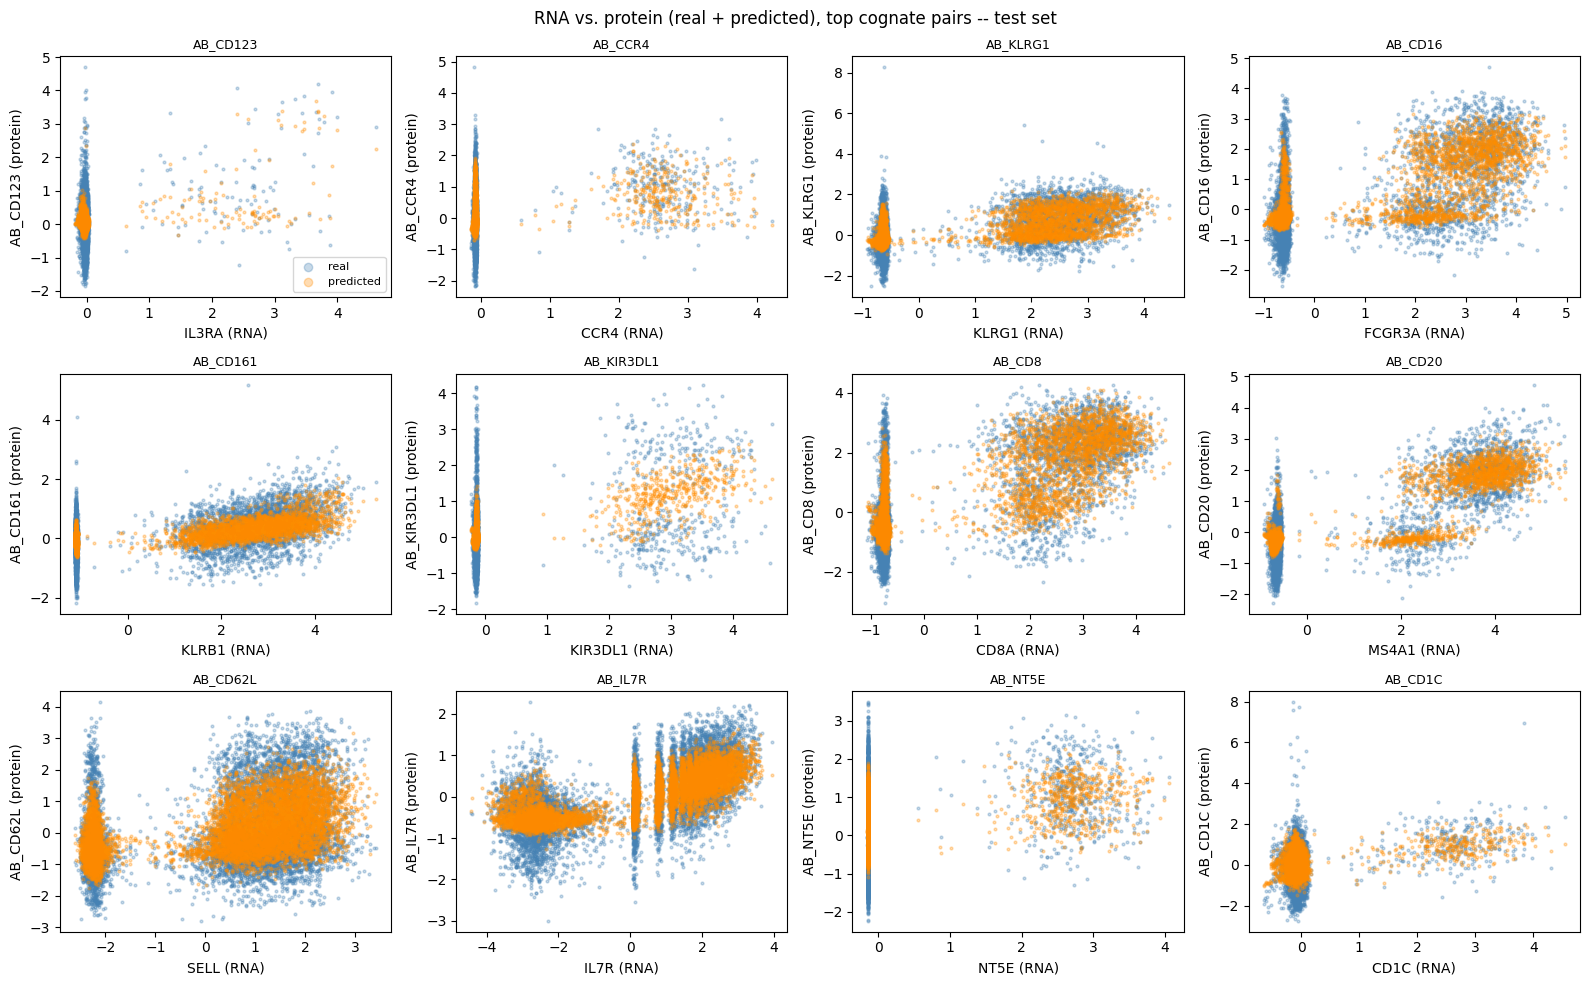

In [22]:
gene_idx_map = {g: i for i, g in enumerate(gene_union)}
protein_idx_map = {p: i for i, p in enumerate(matched_adt_names)}


def plot_rna_vs_protein(ax, gene: str, protein: str,
                         X: np.ndarray, Y_real: np.ndarray, Y_pred: np.ndarray):
    """RNA (x) vs. real and predicted protein (y) on a single axis."""
    gi, pi = gene_idx_map[gene], protein_idx_map[protein]
    x = X[:, gi]
    ax.scatter(x, Y_real[:, pi], s=4, alpha=0.3, color='steelblue', label='real')
    ax.scatter(x, Y_pred[:, pi], s=4, alpha=0.3, color='darkorange', label='predicted')
    ax.set_xlabel(f'{gene} (RNA)')
    ax.set_ylabel(f'{protein} (protein)')
    ax.set_title(protein, fontsize=9)


top_pairs = cognate_ranks.head(N_PLOT_PAIRS)

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, (_, row) in zip(axes.flat, top_pairs.iterrows()):
    plot_rna_vs_protein(ax, row['cognate_gene'], row['protein'], X_rna_corr[test_idx], Y_protein_corr[test_idx], global_test_preds)
axes.flat[0].legend(markerscale=3, fontsize=8)
fig.suptitle('RNA vs. protein (real + predicted), top cognate pairs -- test set')
fig.tight_layout()
plt.show()

In [23]:
# Full set (all 163 cognate pairs), saved to PDF -- not displayed inline
with PdfPages(FIGURES_DIR / 'rna_vs_protein_all_pairs.pdf') as pdf:
    for _, row in cognate_ranks.iterrows():
        fig, ax = plt.subplots(figsize=(5, 4))
        plot_rna_vs_protein(ax, row['cognate_gene'], row['protein'], X_rna_corr[test_idx], Y_protein_corr[test_idx], global_test_preds)
        ax.legend(markerscale=3, fontsize=8)
        pdf.savefig(fig)
        plt.close(fig)

print(f'Saved all {len(cognate_ranks)} RNA-vs-protein plots to {FIGURES_DIR / "rna_vs_protein_all_pairs.pdf"}')

Saved all 163 RNA-vs-protein plots to /content/drive/MyDrive/covid_citeseq_project/results/sparse_mlp_corrected/figures/rna_vs_protein_all_pairs.pdf


## Scatter plots: predicted vs. real protein (calibration)
Direct check of model fit per protein -- points on the diagonal mean accurate prediction.

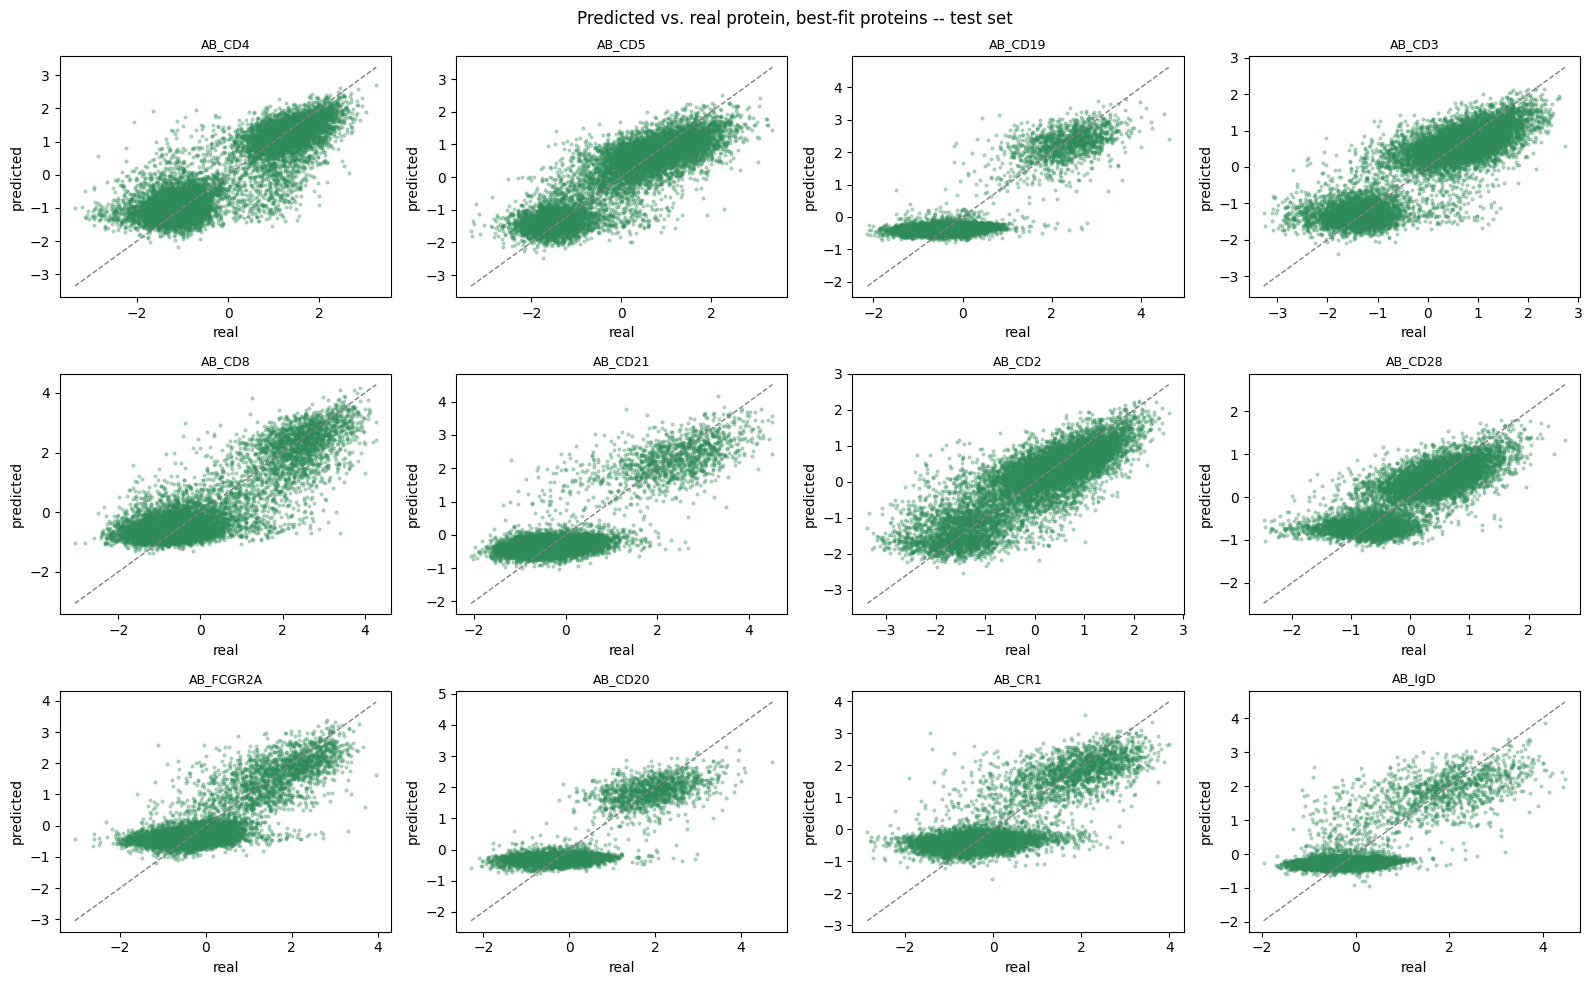

In [24]:
def plot_pred_vs_real(ax, protein: str, Y_real: np.ndarray, Y_pred: np.ndarray):
    """Predicted (y) vs. real (x) protein value, with the y=x reference line."""
    pi = protein_idx_map[protein]
    real, pred = Y_real[:, pi], Y_pred[:, pi]
    ax.scatter(real, pred, s=4, alpha=0.3, color='seagreen')
    lims = [min(real.min(), pred.min()), max(real.max(), pred.max())]
    ax.plot(lims, lims, color='grey', linestyle='--', linewidth=1)
    ax.set_xlabel('real')
    ax.set_ylabel('predicted')
    ax.set_title(protein, fontsize=9)


top_proteins = global_metrics.head(N_PLOT_PAIRS)['protein'].tolist()

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, protein in zip(axes.flat, top_proteins):
    plot_pred_vs_real(ax, protein, Y_protein_corr[test_idx], global_test_preds)
fig.suptitle('Predicted vs. real protein, best-fit proteins -- test set')
fig.tight_layout()
plt.show()

In [25]:
# Full set (all 163 proteins), saved to PDF -- not displayed inline
with PdfPages(FIGURES_DIR / 'pred_vs_real_all_proteins.pdf') as pdf:
    for protein in matched_adt_names:
        fig, ax = plt.subplots(figsize=(4.5, 4.5))
        plot_pred_vs_real(ax, protein, Y_protein_corr[test_idx], global_test_preds)
        pdf.savefig(fig)
        plt.close(fig)

print(f'Saved all {len(matched_adt_names)} predicted-vs-real plots to {FIGURES_DIR / "pred_vs_real_all_proteins.pdf"}')

Saved all 163 predicted-vs-real plots to /content/drive/MyDrive/covid_citeseq_project/results/sparse_mlp_corrected/figures/pred_vs_real_all_proteins.pdf


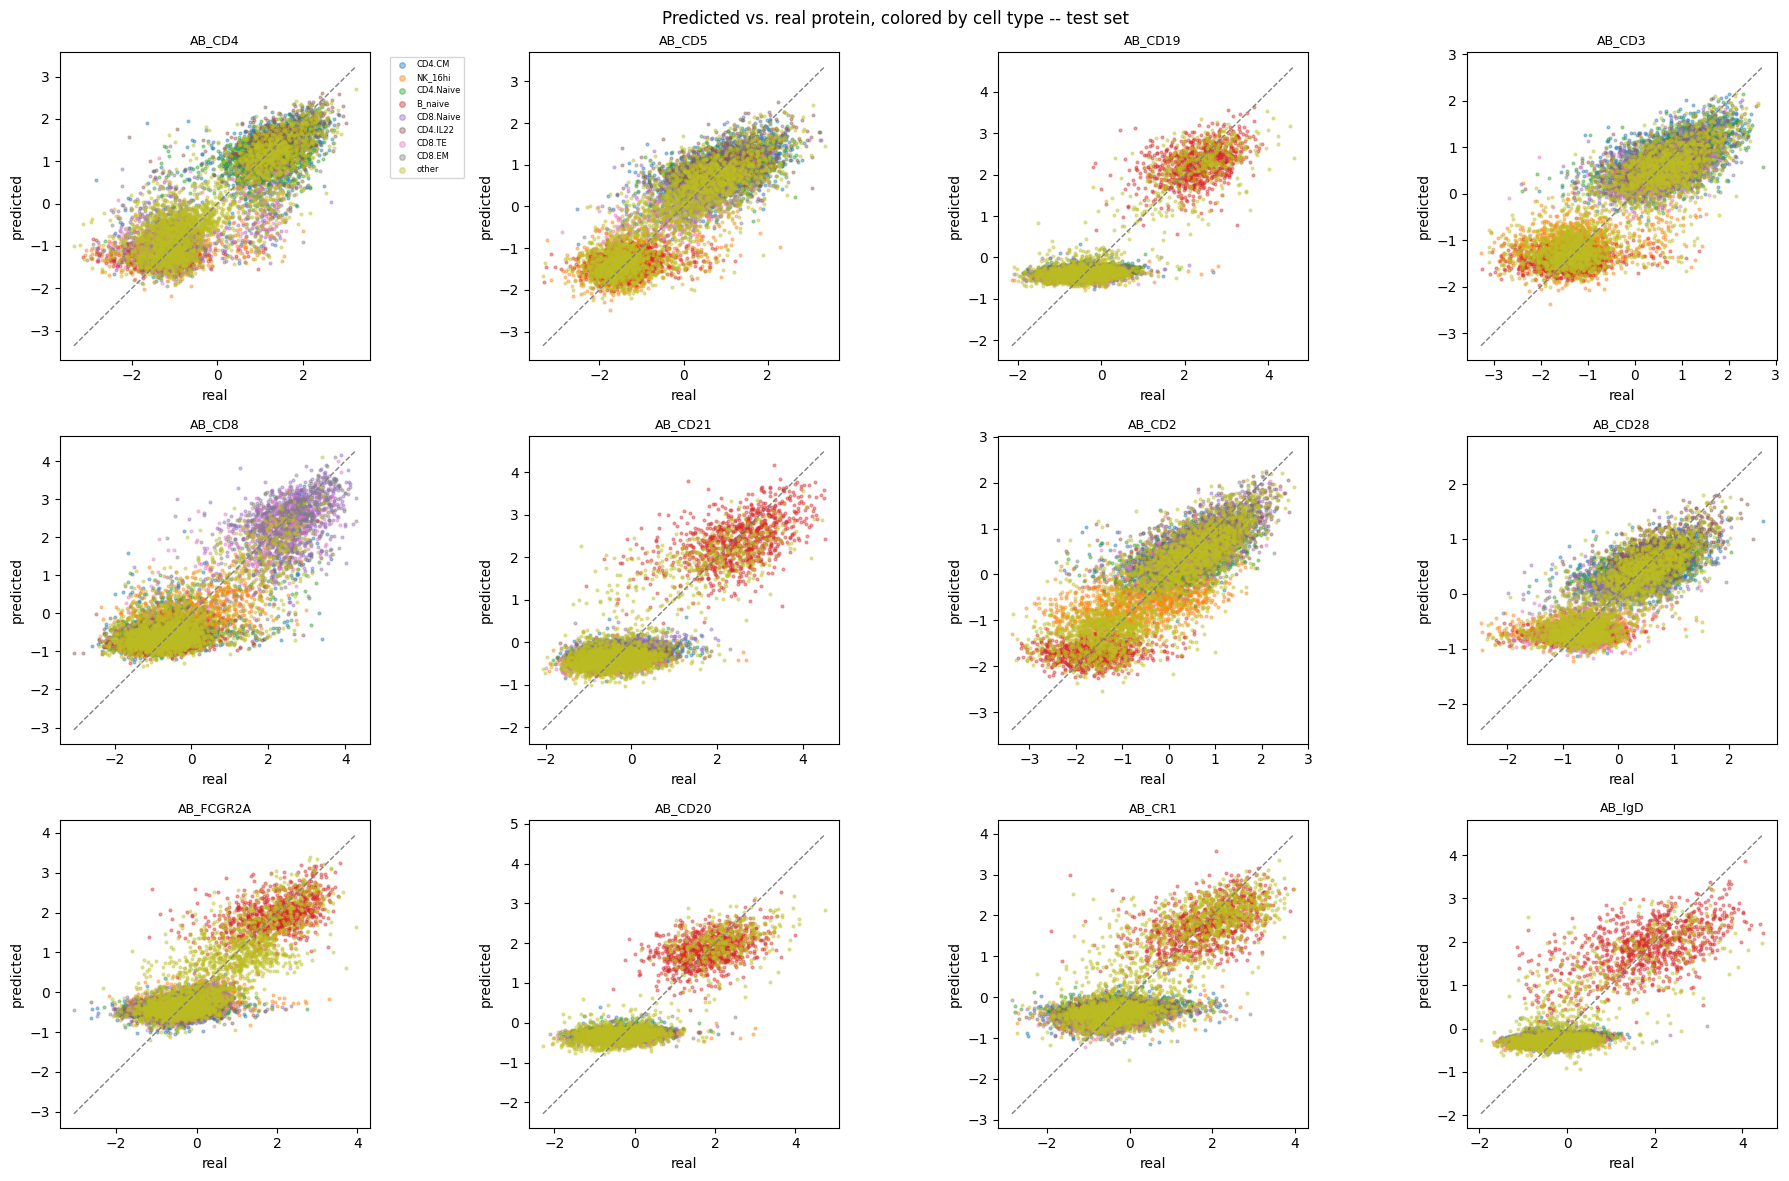

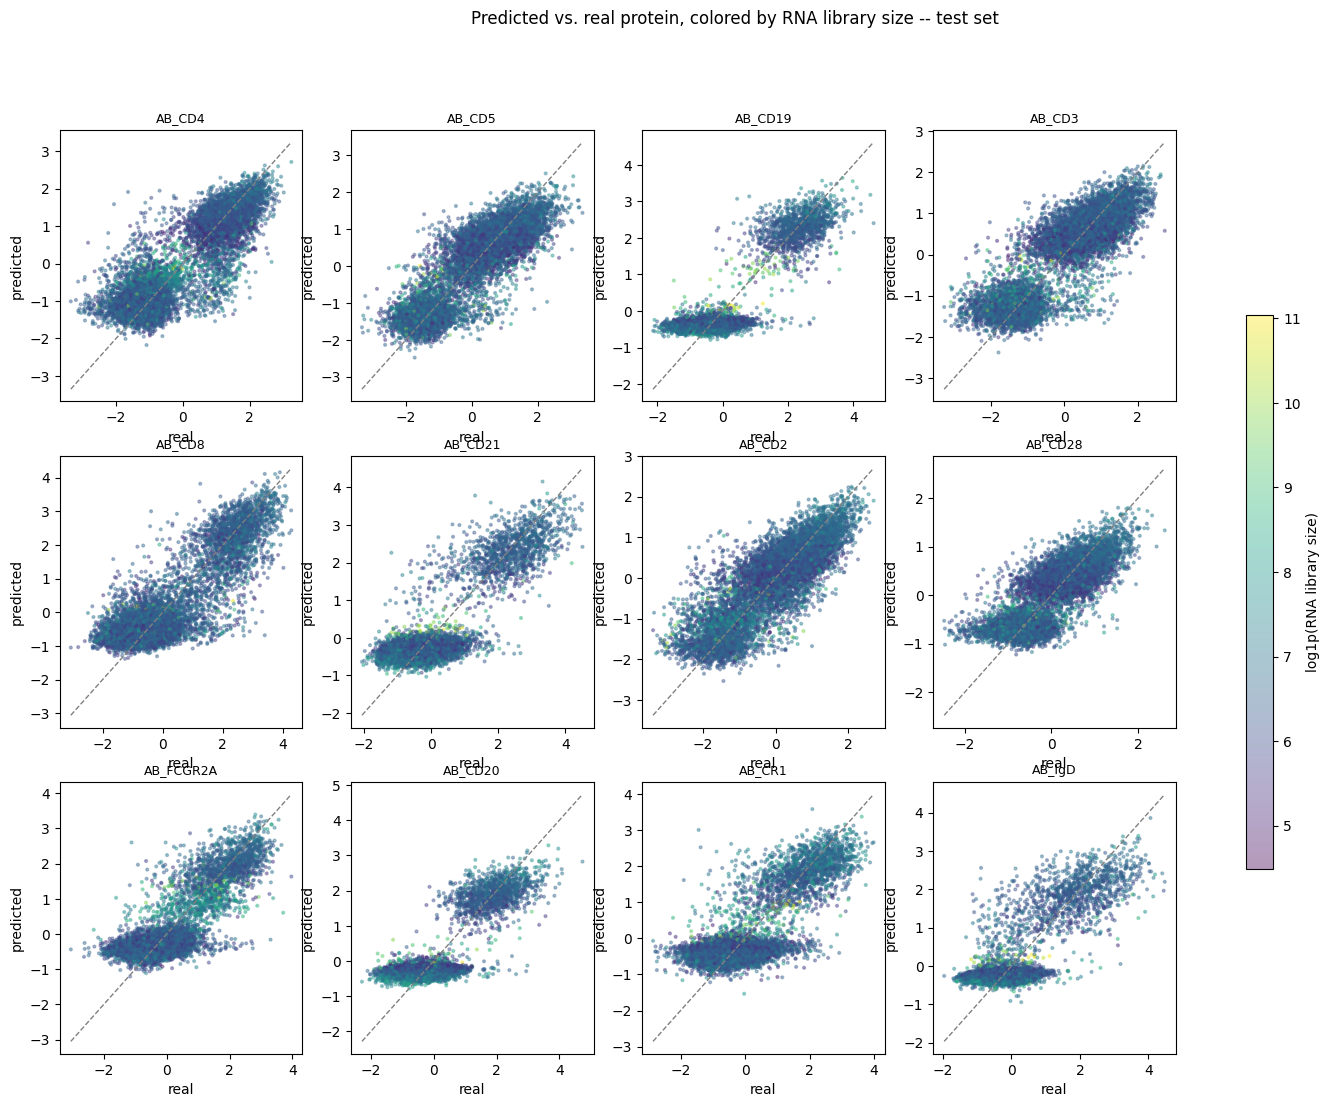

In [29]:
# Diagnostic: color the predicted-vs-real grid by cell type and by library size
# to check whether the two-cluster pattern tracks cell identity / cell size.

test_cell_types = cell_types[test_idx]
test_rna_libsize = np.asarray(rna_raw_for_size[test_idx]).sum(axis=1)
test_protein_libsize = np.asarray(adt_counts[test_idx]).sum(axis=1)

# --- Colored by cell type (top N most frequent types in test set, rest grouped as 'other') ---
top_n_types = 8
type_counts_test = pd.Series(test_cell_types).value_counts()
top_types = type_counts_test.head(top_n_types).index.tolist()
color_labels = np.where(np.isin(test_cell_types.astype(str), top_types), test_cell_types.astype(str), 'other')

cmap = plt.get_cmap('tab10')
type_to_color = {t: cmap(i) for i, t in enumerate(top_types + ['other'])}

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
for ax, protein in zip(axes.flat, top_proteins):
    pi = protein_idx_map[protein]
    real, pred = Y_protein_corr[test_idx][:, pi], global_test_preds[:, pi]
    for t in top_types + ['other']:
        mask = color_labels == t
        ax.scatter(real[mask], pred[mask], s=4, alpha=0.4, color=type_to_color[t], label=t)
    lims = [min(real.min(), pred.min()), max(real.max(), pred.max())]
    ax.plot(lims, lims, color='grey', linestyle='--', linewidth=1)
    ax.set_xlabel('real')
    ax.set_ylabel('predicted')
    ax.set_title(protein, fontsize=9)
axes.flat[0].legend(fontsize=6, markerscale=2, loc='upper left', bbox_to_anchor=(1.05, 1))
fig.suptitle('Predicted vs. real protein, colored by cell type -- test set')
fig.tight_layout()
plt.show()

# --- Colored by RNA library size (continuous) ---
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
for ax, protein in zip(axes.flat, top_proteins):
    pi = protein_idx_map[protein]
    real, pred = Y_protein_corr[test_idx][:, pi], global_test_preds[:, pi]
    sc_plot = ax.scatter(real, pred, s=4, alpha=0.4, c=np.log1p(test_rna_libsize), cmap='viridis')
    lims = [min(real.min(), pred.min()), max(real.max(), pred.max())]
    ax.plot(lims, lims, color='grey', linestyle='--', linewidth=1)
    ax.set_xlabel('real')
    ax.set_ylabel('predicted')
    ax.set_title(protein, fontsize=9)
fig.colorbar(sc_plot, ax=axes, label='log1p(RNA library size)', shrink=0.6)
fig.suptitle('Predicted vs. real protein, colored by RNA library size -- test set')
plt.show()

In [33]:
# Per-cell-type and per-severity evaluation of the GLOBAL model's predictions
# (no retraining -- just grouping the existing test-set predictions)

SEVERITY_COL = 'Status_on_day_collection_summary'  # check covid.obs.columns if this isn't right; also try 'Worst_Clinical_Status'

test_cell_types_arr = cell_types[test_idx]
test_severity_arr = covid.obs[SEVERITY_COL].values[test_idx]

print('Severity groups in test set:')
print(pd.Series(test_severity_arr).value_counts())


def evaluate_by_group(Y_real: np.ndarray, Y_pred: np.ndarray, group_labels: np.ndarray,
                       protein_names: list[str], group_col_name: str,
                       min_cells: int = 50) -> pd.DataFrame:
    """Per-protein Pearson r and R2, computed separately within each group."""
    rows = []
    for group in pd.unique(group_labels):
        mask = group_labels == group
        n = mask.sum()
        if n < min_cells:
            continue
        for i, protein in enumerate(protein_names):
            real, pred = Y_real[mask, i], Y_pred[mask, i]
            if np.std(real) == 0 or np.std(pred) == 0:
                r, r2 = np.nan, np.nan
            else:
                r, _ = pearsonr(real, pred)
                r2 = r2_score(real, pred)
            rows.append({group_col_name: group, 'protein': protein, 'n_cells': n, 'pearson_r': r, 'r2': r2})
    return pd.DataFrame(rows)


# --- Per cell type ---
celltype_pred_eval = evaluate_by_group(
    Y_protein_corr[test_idx], global_test_preds, test_cell_types_arr,
    matched_adt_names, group_col_name='cell_type',
)
celltype_pred_summary = celltype_pred_eval.groupby('cell_type').agg(
    n_cells=('n_cells', 'first'),
    median_r=('pearson_r', 'median'),
    median_r2=('r2', 'median'),
).sort_values('median_r', ascending=False)
print('\nGlobal model performance by cell type:')
print(celltype_pred_summary)

# --- Per severity ---
severity_pred_eval = evaluate_by_group(
    Y_protein_corr[test_idx], global_test_preds, test_severity_arr,
    matched_adt_names, group_col_name='severity',
)
severity_pred_summary = severity_pred_eval.groupby('severity').agg(
    n_cells=('n_cells', 'first'),
    median_r=('pearson_r', 'median'),
    median_r2=('r2', 'median'),
).sort_values('median_r', ascending=False)
print('\nGlobal model performance by severity:')
print(severity_pred_summary)

# Save
celltype_pred_eval.to_csv(RESULTS_DIR / 'global_model_per_celltype_eval.csv', index=False)
severity_pred_eval.to_csv(RESULTS_DIR / 'global_model_per_severity_eval.csv', index=False)

Severity groups in test set:
Healthy         2109
Asymptomatic    2031
Mild            2020
Moderate        1793
Critical        1356
Severe          1055
Name: count, dtype: int64

Global model performance by cell type:
                       n_cells  median_r  median_r2
cell_type                                          
RBC                        153  0.450880   0.163470
DC3                         72  0.395874   0.097305
gdT                        296  0.340861   0.105303
Platelets                  345  0.339529   0.105423
CD4.Tfh                    370  0.339238   0.106713
NKT                         59  0.329988   0.089111
CD8.Naive                  842  0.323602   0.101220
CD8.EM                     402  0.323008   0.096054
NK_56hi                    170  0.307736   0.085797
CD8.TE                     444  0.295222   0.078242
CD4.IL22                   810  0.284065   0.077615
B_immature                 102  0.283742   0.055054
MAIT                       250  0.283125   0.067586

In [32]:
# Per-cell-type and per-severity evaluation of the GLOBAL model -- TRAINING set

train_cell_types_arr = cell_types[train_idx]
train_severity_arr = covid.obs[SEVERITY_COL].values[train_idx]

# --- Per cell type ---
celltype_pred_eval_train = evaluate_by_group(
    Y_protein_corr[train_idx], global_train_preds, train_cell_types_arr,
    matched_adt_names, group_col_name='cell_type',
)
celltype_pred_summary_train = celltype_pred_eval_train.groupby('cell_type').agg(
    n_cells=('n_cells', 'first'),
    median_r=('pearson_r', 'median'),
    median_r2=('r2', 'median'),
).sort_values('median_r', ascending=False)
print('Global model performance by cell type (train):')
print(celltype_pred_summary_train)

# --- Per severity ---
severity_pred_eval_train = evaluate_by_group(
    Y_protein_corr[train_idx], global_train_preds, train_severity_arr,
    matched_adt_names, group_col_name='severity',
)
severity_pred_summary_train = severity_pred_eval_train.groupby('severity').agg(
    n_cells=('n_cells', 'first'),
    median_r=('pearson_r', 'median'),
    median_r2=('r2', 'median'),
).sort_values('median_r', ascending=False)
print('\nGlobal model performance by severity (train):')
print(severity_pred_summary_train)

# Save
celltype_pred_eval_train.to_csv(RESULTS_DIR / 'global_model_per_celltype_eval_train.csv', index=False)
severity_pred_eval_train.to_csv(RESULTS_DIR / 'global_model_per_severity_eval_train.csv', index=False)

Global model performance by cell type (train):
                       n_cells  median_r  median_r2
cell_type                                          
RBC                        776  0.418231   0.164213
DC3                        264  0.383412   0.107817
CD4.Th1                    127  0.363702   0.124641
NKT                        253  0.363696   0.123266
Plasmablast                108  0.355838   0.099474
Platelets                 1602  0.343606   0.113345
gdT                       1337  0.335352   0.111611
CD8.EM                    1673  0.332000   0.105365
CD4.Tfh                   1694  0.331949   0.107768
pDC                        124  0.329632   0.081805
NK_prolif                  131  0.328033   0.095629
HSC_CD38pos                 61  0.326456   0.056248
Treg                       115  0.326360   0.091287
CD4.EM                     164  0.316460   0.088652
NK_56hi                    843  0.315013   0.095592
CD8.Naive                 3891  0.314777   0.097381
B_exhausted      

In [34]:
# Severity breakdown WITHIN fixed cell types -- tests whether the severity gradient
# is a real coupling effect or just cell-type composition shifting with severity.

MIN_CELLS_PER_GROUP = 300  # per cell-type x severity cell, to keep correlations stable

# Restrict to well-populated cell types so each severity subgroup still has enough cells
well_populated_types = celltype_pred_summary_train[celltype_pred_summary_train['n_cells'] >= 2000].index.tolist()
print(f'Checking within: {well_populated_types}')

within_celltype_severity_rows = []

for ct in well_populated_types:
    ct_mask = train_cell_types_arr == ct
    ct_train_positions = np.where(ct_mask)[0]  # positions within train_idx

    ct_eval = evaluate_by_group(
        Y_protein_corr[train_idx][ct_train_positions],
        global_train_preds[ct_train_positions],
        train_severity_arr[ct_train_positions],
        matched_adt_names,
        group_col_name='severity',
        min_cells=MIN_CELLS_PER_GROUP,
    )
    ct_summary = ct_eval.groupby('severity').agg(
        n_cells=('n_cells', 'first'),
        median_r=('pearson_r', 'median'),
    ).reset_index()
    ct_summary['cell_type'] = ct
    within_celltype_severity_rows.append(ct_summary)

within_celltype_severity = pd.concat(within_celltype_severity_rows, ignore_index=True)

# Pivot for easy visual comparison: rows = cell type, cols = severity, values = median r
pivot = within_celltype_severity.pivot(index='cell_type', columns='severity', values='median_r')
pivot['range'] = pivot.max(axis=1) - pivot.min(axis=1)
pivot = pivot.sort_values('range', ascending=False)

print('\nMedian Pearson r by severity, WITHIN each fixed cell type:')
print(pivot)
print(f'\nFor comparison, the pooled (composition-confounded) severity range was: '
      f'{severity_pred_summary_train["median_r"].max() - severity_pred_summary_train["median_r"].min():.3f}')

within_celltype_severity.to_csv(RESULTS_DIR / 'within_celltype_severity_eval_train.csv', index=False)

Checking within: ['CD8.Naive', 'B_naive', 'CD4.CM', 'CD4.IL22', 'CD8.TE', 'NK_16hi', 'CD4.Naive']

Median Pearson r by severity, WITHIN each fixed cell type:
severity   Asymptomatic  Critical   Healthy      Mild  Moderate    Severe  \
cell_type                                                                   
CD4.IL22       0.302152  0.388798  0.151266  0.239826  0.202483  0.328762   
CD4.CM         0.297555  0.373641  0.158526  0.294138  0.241197  0.296075   
CD4.Naive      0.237459  0.330044  0.158228  0.279075  0.204845  0.198269   
B_naive        0.344430  0.273380  0.178888  0.274227  0.238263  0.294358   
CD8.Naive      0.313323  0.350648  0.189874  0.332796  0.267891       NaN   
CD8.TE         0.324190       NaN       NaN  0.176529  0.243947       NaN   
NK_16hi        0.260013  0.280449  0.168598  0.273454  0.250863  0.234875   

severity      range  
cell_type            
CD4.IL22   0.237531  
CD4.CM     0.215115  
CD4.Naive  0.171817  
B_naive    0.165543  
CD8.Naive  0.160

In [35]:
# Patient-identity check: is the severity gradient actually a per-patient effect?

train_patient_arr = covid.obs['patient_id'].values[train_idx]

# --- Step 1: how many distinct patients feed each severity tier, within each fixed cell type ---
patient_coverage_rows = []
for ct in well_populated_types:
    ct_mask = train_cell_types_arr == ct
    for sev in pd.unique(train_severity_arr[ct_mask]):
        sev_mask = ct_mask & (train_severity_arr == sev)
        n_cells = sev_mask.sum()
        n_patients = pd.unique(train_patient_arr[sev_mask]).size
        if n_cells >= MIN_CELLS_PER_GROUP:
            patient_coverage_rows.append({
                'cell_type': ct, 'severity': sev, 'n_cells': n_cells, 'n_patients': n_patients,
                'cells_per_patient': n_cells / n_patients,
            })

patient_coverage = pd.DataFrame(patient_coverage_rows).sort_values(['cell_type', 'severity'])
print('Patients contributing to each cell_type x severity cell:')
print(patient_coverage)

# --- Step 2: redo the fit-quality breakdown by PATIENT instead of severity, within fixed cell types ---
MIN_CELLS_PER_PATIENT = 150

within_celltype_patient_rows = []
for ct in well_populated_types:
    ct_mask = train_cell_types_arr == ct
    ct_positions = np.where(ct_mask)[0]

    ct_eval = evaluate_by_group(
        Y_protein_corr[train_idx][ct_positions],
        global_train_preds[ct_positions],
        train_patient_arr[ct_positions],
        matched_adt_names,
        group_col_name='patient_id',
        min_cells=MIN_CELLS_PER_PATIENT,
    )
    ct_summary = ct_eval.groupby('patient_id').agg(
        n_cells=('n_cells', 'first'),
        median_r=('pearson_r', 'median'),
    ).reset_index()
    ct_summary['cell_type'] = ct
    within_celltype_patient_rows.append(ct_summary)

within_celltype_patient = pd.concat(within_celltype_patient_rows, ignore_index=True)

# attach each patient's severity label for comparison
patient_to_severity = pd.Series(train_severity_arr, index=train_patient_arr).drop_duplicates()
within_celltype_patient['severity'] = within_celltype_patient['patient_id'].map(patient_to_severity)

pivot_patient = within_celltype_patient.pivot_table(
    index=['cell_type'], columns='patient_id', values='median_r'
)
print('\nMedian Pearson r by individual PATIENT, within each fixed cell type:')
print(within_celltype_patient.sort_values(['cell_type', 'median_r'], ascending=[True, False]).to_string(index=False))

# --- Step 3: compare within-severity, cross-patient spread to across-severity spread ---
variance_check = within_celltype_patient.groupby(['cell_type', 'severity'])['median_r'].agg(['min', 'max', 'std', 'count'])
variance_check['patient_range'] = variance_check['max'] - variance_check['min']
print('\nSpread ACROSS PATIENTS within the same severity tier (same cell type):')
print(variance_check)

within_celltype_patient.to_csv(RESULTS_DIR / 'within_celltype_per_patient_eval_train.csv', index=False)
patient_coverage.to_csv(RESULTS_DIR / 'patient_coverage_per_celltype_severity.csv', index=False)

Patients contributing to each cell_type x severity cell:
    cell_type      severity  n_cells  n_patients  cells_per_patient
6     B_naive  Asymptomatic      856           3         285.333333
5     B_naive      Critical      712           3         237.333333
7     B_naive       Healthy      471           3         157.000000
8     B_naive          Mild     1009           3         336.333333
9     B_naive      Moderate      575           3         191.666667
10    B_naive        Severe      482           3         160.666667
15     CD4.CM  Asymptomatic     1490           3         496.666667
16     CD4.CM      Critical     1010           3         336.666667
12     CD4.CM       Healthy     1918           3         639.333333
11     CD4.CM          Mild     2204           3         734.666667
14     CD4.CM      Moderate     1539           3         513.000000
13     CD4.CM        Severe      574           3         191.333333
21   CD4.IL22  Asymptomatic      480           3         16

In [36]:
# --- 1. Within-cluster Pearson r check ---
# For each protein, split cells into low/high populations via a 2-component GMM
# on the REAL protein value, then check Pearson r separately within each cluster.
# If within-cluster r collapses relative to the overall r, the model is mostly
# doing on/off separation, not capturing continuous regulation.

from sklearn.mixture import GaussianMixture

def within_cluster_correlation(Y_real: np.ndarray, Y_pred: np.ndarray, protein_names: list[str]) -> pd.DataFrame:
    """Overall r vs. within-cluster r (low/high populations found via 2-component GMM)."""
    rows = []
    for i, protein in enumerate(protein_names):
        real, pred = Y_real[:, i], Y_pred[:, i]
        overall_r, _ = pearsonr(real, pred)

        gmm = GaussianMixture(n_components=2, random_state=RANDOM_STATE, n_init=3)
        labels = gmm.fit_predict(real.reshape(-1, 1))
        means = [real[labels == k].mean() for k in range(2)]
        low_label, high_label = np.argsort(means)

        row = {'protein': protein, 'overall_r': overall_r}
        for name, lbl in [('low', low_label), ('high', high_label)]:
            mask = labels == lbl
            n = mask.sum()
            if n >= 30 and np.std(real[mask]) > 0 and np.std(pred[mask]) > 0:
                r, _ = pearsonr(real[mask], pred[mask])
            else:
                r = np.nan
            row[f'{name}_cluster_r'] = r
            row[f'{name}_cluster_n'] = n
        rows.append(row)
    return pd.DataFrame(rows)


within_cluster = within_cluster_correlation(Y_protein_corr[test_idx], global_test_preds, matched_adt_names)
within_cluster['within_cluster_mean_r'] = within_cluster[['low_cluster_r', 'high_cluster_r']].mean(axis=1)
within_cluster = within_cluster.sort_values('overall_r', ascending=False)

print(f"Median overall r:        {within_cluster['overall_r'].median():.3f}")
print(f"Median within-cluster r: {within_cluster['within_cluster_mean_r'].median():.3f}")
within_cluster.to_csv(RESULTS_DIR / 'within_cluster_correlation.csv', index=False)
within_cluster.head(20)

Median overall r:        0.442
Median within-cluster r: 0.333


,protein,overall_r,low_cluster_r,low_cluster_n,high_cluster_r,high_cluster_n,within_cluster_mean_r
31,AB_CD4,0.875520,0.265519,5486,0.489173,4878,0.377346
46,AB_CD5,0.875273,0.363791,3616,0.593632,6748,0.478712
19,AB_CD19,0.861010,0.230737,9075,0.434917,1289,0.332827
16,AB_CD3,0.861001,0.378127,3737,0.534222,6627,0.456174
17,AB_CD8,0.850840,0.312533,8133,0.585659,2231,0.449096
80,AB_CD21,0.842837,0.266920,9129,0.594634,1235,0.430777
104,AB_CD2,0.831557,0.424087,2954,0.631147,7410,0.527617
113,AB_CD28,0.812905,0.408778,5180,0.542412,5184,0.475595
49,AB_FCGR2A,0.807522,0.360135,8774,0.538164,1590,0.449150
38,AB_CD20,0.806130,0.278860,9170,0.392178,1194,0.335519


In [37]:
# --- 2. Size-matched stratified vs. global comparison ---
# For each cell type, train N random-subsample baseline models on ALL cells,
# matched in size to that cell type's training set, then compare their test
# performance (on that cell type's held-out cells) to the dedicated stratified
# model. This isolates whether stratification adds real signal, independent
# of just having less training data.
# NOTE: trains len(fit_types) * N_RANDOM_SUBSAMPLES extra models -- reduce
# N_RANDOM_SUBSAMPLES to 1 first if you want a quick pass before the full run.

N_RANDOM_SUBSAMPLES = 3

def train_size_matched_baseline(n_train_cells: int, seed: int) -> nn.Module:
    """Train a global-style model on a random subsample of ALL cells, size-matched
    to a given cell type's training set."""
    rng = np.random.RandomState(seed)
    sub_idx = rng.choice(train_idx, size=n_train_cells, replace=False)
    sub_train, sub_val = train_test_split(sub_idx, test_size=VAL_SIZE, random_state=seed)

    sub_train_loader = make_loader(X_rna_corr, Y_protein_corr, sub_train, BATCH_SIZE, shuffle=True)
    sub_val_loader   = make_loader(X_rna_corr, Y_protein_corr, sub_val,   BATCH_SIZE, shuffle=False)

    model = SparseGeneToProteinMLP(
        rna_dim=X_rna_corr.shape[1], hidden_dim=HIDDEN_DIM, protein_dim=Y_protein_corr.shape[1],
    )
    model, _ = fit_sparse_mlp(
        model=model,
        train_loader=sub_train_loader,
        val_loader=sub_val_loader,
        l1_lambda=L1_LAMBDA,
        num_epochs=NUM_EPOCHS,
        patience=PATIENCE,
        checkpoint_path=MODELS_DIR / f'sizematched_seed{seed}.pt',
        train_device=DEVICE,
    )
    return model


size_matched_rows = []

for ct in fit_types:
    n_train_ct = len(celltype_splits[ct]['train'])
    ct_test_idx = celltype_splits[ct]['test']

    stratified_metrics = evaluate_per_protein(
        celltype_models[ct], X_rna_corr[ct_test_idx], Y_protein_corr[ct_test_idx], matched_adt_names,
    )
    stratified_median_r = stratified_metrics['pearson_r'].median()

    baseline_rs = []
    for seed in range(N_RANDOM_SUBSAMPLES):
        baseline_model = train_size_matched_baseline(n_train_ct, seed=1000 + seed)
        baseline_metrics = evaluate_per_protein(
            baseline_model, X_rna_corr[ct_test_idx], Y_protein_corr[ct_test_idx], matched_adt_names,
        )
        baseline_rs.append(baseline_metrics['pearson_r'].median())

    size_matched_rows.append({
        'cell_type': ct,
        'n_train_cells': n_train_ct,
        'stratified_median_r': stratified_median_r,
        'size_matched_baseline_r_mean': np.mean(baseline_rs),
        'size_matched_baseline_r_std': np.std(baseline_rs),
        'stratified_vs_sizematched_gain': stratified_median_r - np.mean(baseline_rs),
    })
    print(f'{ct}: stratified={stratified_median_r:.3f}, '
          f'size-matched={np.mean(baseline_rs):.3f} (+/-{np.std(baseline_rs):.3f})')

size_matched_comparison = pd.DataFrame(size_matched_rows).sort_values('stratified_vs_sizematched_gain', ascending=False)
size_matched_comparison.to_csv(RESULTS_DIR / 'size_matched_vs_stratified.csv', index=False)
size_matched_comparison

  Epoch 0: train_loss=0.4429, val_loss=0.3256
  Epoch 10: train_loss=0.2839, val_loss=0.2767
  Epoch 20: train_loss=0.2767, val_loss=0.2751
  Epoch 30: train_loss=0.2724, val_loss=0.2741
  Epoch 40: train_loss=0.2703, val_loss=0.2746
  Early stopping at epoch 44
  Epoch 0: train_loss=0.4441, val_loss=0.3283
  Epoch 10: train_loss=0.2831, val_loss=0.2775
  Epoch 20: train_loss=0.2760, val_loss=0.2743
  Epoch 30: train_loss=0.2723, val_loss=0.2743
  Epoch 40: train_loss=0.2695, val_loss=0.2738
  Early stopping at epoch 50
  Epoch 0: train_loss=0.4396, val_loss=0.3251
  Epoch 10: train_loss=0.2841, val_loss=0.2781
  Epoch 20: train_loss=0.2766, val_loss=0.2760
  Epoch 30: train_loss=0.2727, val_loss=0.2741
  Epoch 40: train_loss=0.2698, val_loss=0.2749
  Early stopping at epoch 44
CD4.CM: stratified=0.278, size-matched=0.254 (+/-0.005)
  Epoch 0: train_loss=0.4710, val_loss=0.3479
  Epoch 10: train_loss=0.2837, val_loss=0.2845
  Epoch 20: train_loss=0.2735, val_loss=0.2807
  Epoch 30: tra

,cell_type,n_train_cells,stratified_median_r,size_matched_baseline_r_mean,size_matched_baseline_r_std,stratified_vs_sizematched_gain
14,RBC,755,0.400203,0.228673,0.013370,0.171530
7,CD83_CD14_mono,1753,0.214669,0.122874,0.006174,0.091795
16,B_immature,506,0.139601,0.059670,0.022912,0.079931
3,B_naive,4144,0.251024,0.174047,0.005267,0.076977
15,B_switched_memory,742,0.149061,0.078355,0.022176,0.070706
6,CD8.TE,1999,0.226652,0.156202,0.003459,0.070450
8,CD8.EM,1701,0.257642,0.191217,0.012979,0.066425
10,Platelets,1571,0.274882,0.210909,0.005921,0.063973
13,NK_56hi,826,0.173574,0.115827,0.006364,0.057747
9,CD4.Tfh,1693,0.220362,0.166366,0.004347,0.053996


## Save results

In [26]:
global_metrics.to_csv(RESULTS_DIR / 'global_per_protein_metrics.csv', index=False)
cognate_ranks.to_csv(RESULTS_DIR / 'global_cognate_gene_ranks.csv', index=False)
celltype_eval.to_csv(RESULTS_DIR / 'per_celltype_per_protein_metrics.csv', index=False)
summary.to_csv(RESULTS_DIR / 'per_celltype_summary.csv', index=False)
importance_df.to_parquet(RESULTS_DIR / 'global_gene_protein_importance.parquet')

print(f'Saved to {RESULTS_DIR}')
print('  global_per_protein_metrics.csv          -- global model, train/test Pearson r + R2')
print('  global_cognate_gene_ranks.csv            -- cognate RNA rank per protein (corrected)')
print('  per_celltype_per_protein_metrics.csv     -- global vs stratified, per cell type per protein')
print('  per_celltype_summary.csv                 -- median r by cell type, global vs stratified')
print('  global_gene_protein_importance.parquet   -- full importance matrix')
print(f'  figures/rna_vs_protein_all_pairs.pdf     -- all {len(cognate_ranks)} cognate pairs')
print(f'  figures/pred_vs_real_all_proteins.pdf    -- all {len(matched_adt_names)} proteins')

Saved to /content/drive/MyDrive/covid_citeseq_project/results/sparse_mlp_corrected
  global_per_protein_metrics.csv          -- global model, train/test Pearson r + R2
  global_cognate_gene_ranks.csv            -- cognate RNA rank per protein (corrected)
  per_celltype_per_protein_metrics.csv     -- global vs stratified, per cell type per protein
  per_celltype_summary.csv                 -- median r by cell type, global vs stratified
  global_gene_protein_importance.parquet   -- full importance matrix
  figures/rna_vs_protein_all_pairs.pdf     -- all 163 cognate pairs
  figures/pred_vs_real_all_proteins.pdf    -- all 163 proteins
